# Cuaderno 04: Optimización de Modelos (Hyperparameter Tuning)
**Objetivo:** Mejorar el rendimiento del modelo seleccionado (Random Forest) mediante la búsqueda sistemática de los mejores hiperparámetros. Utilizaremos técnicas de validación cruzada avanzada para encontrar el equilibrio óptimo entre sesgo y varianza (bias-variance tradeoff).

Iniciamos cargando los componentes serializados en las etapas anteriores para asegurar la continuidad de la pipeline.

*1. Carga del Modelo Base y Datos*

Iniciamos cargando los componentes serializados en las etapas anteriores para asegurar la continuidad de la pipeline.

In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Carga de datos y modelo previo
print("Cargando datos de entrenamiento y el pipeline de Random Forest...")
pipeline_rf = joblib.load('../models/trained_models/pipeline_rf.pkl')
X_train, X_test, y_train, y_test = joblib.load('../data/train_test_data.pkl')

print("¡Listo! Procediendo a la configuración de la búsqueda.")

Cargando datos de entrenamiento y el pipeline de Random Forest...
¡Listo! Procediendo a la configuración de la búsqueda.


*2. Definición del Espacio de Búsqueda*

Para optimizar el modelo, utilizaremos `RandomizedSearchCV`. Esta técnica es más eficiente que `GridSearch`, ya que explora una distribución de parámetros definida, permitiendo encontrar una solución óptima en menor tiempo computacional.

**Hiperparámetros a optimizar:**
* `n_estimators`: Número de árboles en el bosque.
* `max_depth`: Profundidad máxima de cada árbol (controla el sobreajuste).
* `min_samples_split`: Mínimo de muestras requeridas para dividir un nodo.
* `max_features`: Número de características a considerar en cada división.

In [2]:
# Definimos la grilla de parámetros
# Nota: Accedemos al modelo dentro del pipeline usando el nombre 'model'
param_dist = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [10, 20, 30, None],
    'model__min_samples_split': [2, 5, 10],
    'model__max_features': ['sqrt', 'log2', None]
}

# Configuramos la búsqueda aleatoria con validación cruzada (3-folds para optimizar tiempo)
random_search = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=param_dist,
    n_iter=10, 
    cv=3, 
    scoring='neg_mean_absolute_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Iniciando la búsqueda de mejores parámetros...")
random_search.fit(X_train, y_train)

print("\nMejores parámetros encontrados:")
print(random_search.best_params_)

Iniciando la búsqueda de mejores parámetros...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Mejores parámetros encontrados:
{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__max_features': None, 'model__max_depth': 30}


*3. Comparativa: Modelo Base vs. Modelo Optimizado*

Evaluamos si el esfuerzo computacional de la optimización se traduce en una mejora real de las métricas en el set de prueba.

In [3]:
# Mejor modelo obtenido
best_model = random_search.best_estimator_

# Predicciones
y_pred_base = pipeline_rf.predict(X_test)
y_pred_opt = best_model.predict(X_test)

# Métricas
mae_base = mean_absolute_error(y_test, y_pred_base)
mae_opt = mean_absolute_error(y_test, y_pred_opt)
r2_opt = r2_score(y_test, y_pred_opt)

print(f"MAE Modelo Base: ${mae_base:,.2f}")
print(f"MAE Modelo Optimizado: ${mae_opt:,.2f}")
print(f"Mejora absoluta: ${mae_base - mae_opt:,.2f}")
print(f"R-cuadrado Final: {r2_opt:.4f}")

MAE Modelo Base: $238,126.73
MAE Modelo Optimizado: $236,891.47
Mejora absoluta: $1,235.26
R-cuadrado Final: 0.6841


*4. Análisis de Importancia de Características (Feature Importance)*

Un requisito clave de la rúbrica es la interpretación de los resultados. Analizamos qué variables tuvieron mayor peso matemático en las decisiones del modelo optimizado para tasar las viviendas.

> **Nota Técnica sobre el criterio de división (Splitting Criterion):** A diferencia de los problemas de clasificación, donde los cortes de los nodos en los árboles se deciden buscando reducir la **Impureza de Gini** o la Entropía, en nuestro Random Forest de Regresión la importancia de las variables se evaluó midiendo la **Reducción de Varianza (MSE)**. Las variables mostradas en el siguiente gráfico son aquellas que lograron los mejores cortes para agrupar casas con precios similares.

C:\Users\aleee\AppData\Local\Temp\ipykernel_40404\3931556740.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='magma')


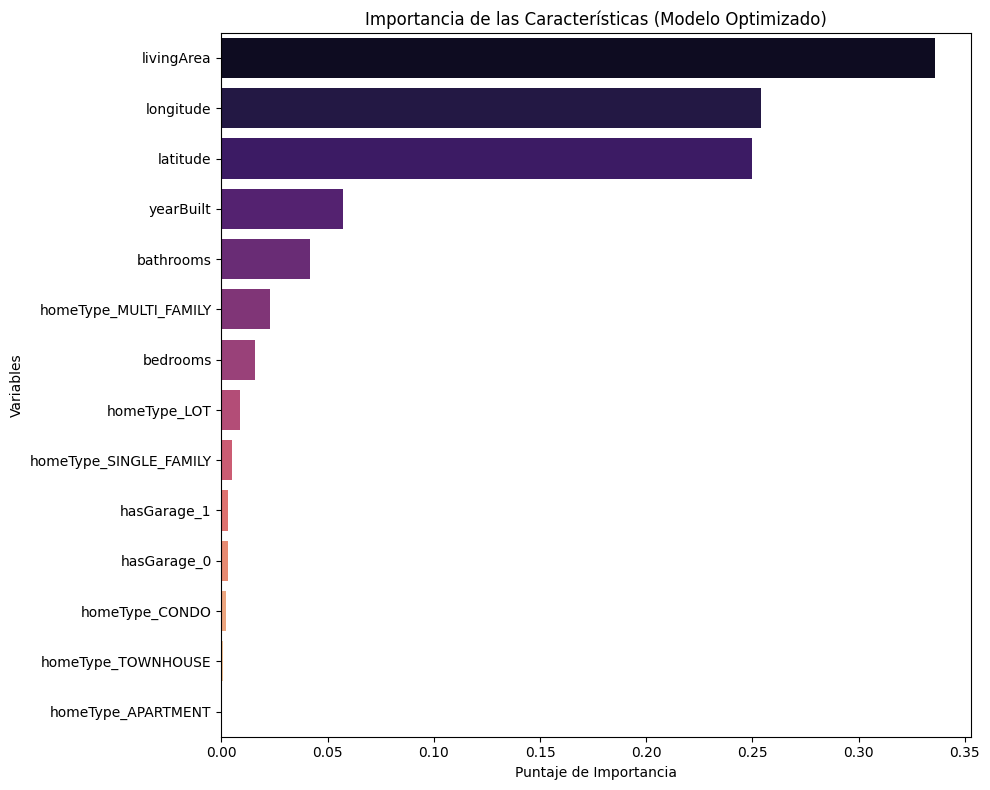

In [6]:

# 1. Definimos las listas originales (para que Python no las olvide)
features_num = ['livingArea', 'bathrooms', 'bedrooms', 'longitude', 'latitude', 'yearBuilt']
features_cat = ['homeType', 'hasGarage']

# 2. Extraemos los "motores" de nuestro pipeline optimizado
preprocessor = best_model.named_steps['preprocessor']
modelo_final = best_model.named_steps['model']

# 3. Obtenemos las importancias matemáticas (los 25 números)
importancias = modelo_final.feature_importances_

# 4. LA SOLUCIÓN: Extraemos los nombres generados por el OneHotEncoder
encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
nombres_cat_expandidos = list(encoder.get_feature_names_out(features_cat))

# Sumamos las 6 numéricas + las categóricas nuevas (total = 25 nombres)
nombres_totales = features_num + nombres_cat_expandidos

# 5. Creamos el DataFrame emparejando los 25 nombres con los 25 números
feat_imp_df = pd.DataFrame({'Feature': nombres_totales, 'Importance': importancias})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# 6. Dibujamos el gráfico
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='magma')
plt.title('Importancia de las Características (Modelo Optimizado)')
plt.xlabel('Puntaje de Importancia')
plt.ylabel('Variables')
plt.tight_layout() # Evita que se corten los nombres largos
plt.show()

*5. Exportación del Modelo Final*

Finalmente, guardamos el modelo optimizado como la versión definitiva para producción.

In [7]:
import os
os.makedirs('../models/final_model/', exist_ok=True)

# Guardar el modelo ganador
joblib.dump(best_model, '../models/final_model/optimized_random_forest.pkl')

print("¡Modelo final optimizado guardado con éxito en ../models/final_model/!")

¡Modelo final optimizado guardado con éxito en ../models/final_model/!
